In [1]:
import plotly.graph_objects as go
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import numpy as np

In [2]:
ticker = "MSTR"
start_date = "2025-01-01"
end_date = "2026-06-13"

df = yf.download(ticker, start=start_date, end=end_date)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.to_csv("Stock.csv")

C:\Users\cjdan\AppData\Local\Temp\ipykernel_34028\3440246803.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [17]:
# --- Define Split Ratio ---
train_ratio = 0.8  # 80% for training, 20% for testing
total_days = len(df)
split_idx = int(total_days * train_ratio)

# --- Split the Data Chronologically ---
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

print(f"Total Rows: {total_days}")
print(f"Training Rows (First 80%): {len(train_df)} (From {train_df.index[0].date()} to {train_df.index[-1].date()})")
print(f"Testing Rows (Last 20%): {len(test_df)} (From {test_df.index[0].date()} to {test_df.index[-1].date()})")

# --- Extract Features Separately ---
train_features = train_df[['Open', 'Close']].to_numpy()
test_features = test_df[['Open', 'Close']].to_numpy()

Total Rows: 362
Training Rows (First 80%): 289 (From 2025-01-02 to 2026-02-27)
Testing Rows (Last 20%): 73 (From 2026-03-02 to 2026-06-12)


In [18]:
# 1. Fit the scaler on TRAINING data only
train_min = train_features.min(axis=0)
train_max = train_features.max(axis=0)

# 2. Scale the training windows
T = train_features.shape[0]
window_data_train = train_features[0:T, :]
scaled_window_train = (window_data_train - train_min) / (train_max - train_min)
inputVar_train = scaled_window_train.T  # Shape: (2, T)

# 3. Scale the testing windows using TRAINING parameters
T_test = test_features.shape[0]
window_data_test = test_features[0:T_test, :]
scaled_window_test = (window_data_test - train_min) / (train_max - train_min)
inputVar_test = scaled_window_test.T  # Shape: (2, T_test)

In [19]:
# Input-to-Hidden weights == (3, 2)
WxH = np.array([
    [ 0.5, -0.2],
    [ 0.1,  0.8],
    [-0.4,  0.3]
])  

# Hidden-to-Hidden weights == (3, 3)
WhH = np.array([
    [ 0.9,  0.1, -0.2],
    [ 0.0,  0.8,  0.3],
    [-0.1,  0.2,  0.7]
])  

# Hidden-to-Output weights

WhY = np.array([
    [ 0.4, -0.5,  0.2],
    [-0.3,  0.7,  0.1]
])  

# Biases
hS0 = np.zeros((3, 1))  
hS0_train = np.zeros((3,1))
biasWV = np.zeros((3, 1))
biasWY = np.zeros((2, 1))

In [20]:
# tanh (from scratch), with clipping to avoid exp() overflow on large inputs
def tanh(x):
    x = np.clip(x, -30, 30)
    return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))

Epoch    0 | MSE Loss: 0.032383
Epoch   20 | MSE Loss: 0.009991
Epoch   40 | MSE Loss: 0.008923
Epoch   60 | MSE Loss: 0.008274
Epoch   80 | MSE Loss: 0.007806
Epoch  100 | MSE Loss: 0.007467
Epoch  120 | MSE Loss: 0.007215
Epoch  140 | MSE Loss: 0.007010
Epoch  160 | MSE Loss: 0.006837
Epoch  180 | MSE Loss: 0.006692
Epoch  200 | MSE Loss: 0.006570
Epoch  220 | MSE Loss: 0.006467
Epoch  240 | MSE Loss: 0.006381
Epoch  260 | MSE Loss: 0.006307
Epoch  280 | MSE Loss: 0.006246
Epoch  299 | MSE Loss: 0.006765


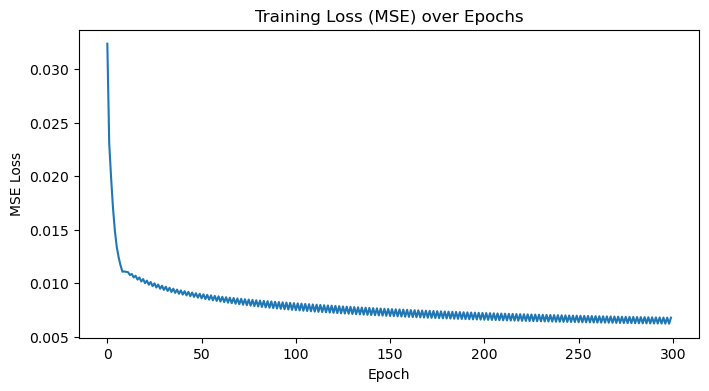

Predicted next-day (Open, Close) after training window: [ 94.08504495 112.88502663]


In [32]:
num_epochs = 300
learning_rate = 0.001
clip_value = 5.0
loss_history = []

for epoch in range(num_epochs):
    # ---- Forward pass ----
    hidden_states_train = []
    outputs_train = []
    hS_current = hS0_train.copy()

    for t in range(T):
        xt = inputVar_train[:, t].reshape(2, 1)
        hState_train = tanh(np.dot(WxH, xt) + np.dot(WhH, hS_current) + biasWV)
        outputVal_train = np.dot(WhY, hState_train) + biasWY

        hidden_states_train.append(hState_train)
        outputs_train.append(outputVal_train)
        hS_current = hState_train

    targets_train = [inputVar_train[:, t + 1].reshape(2, 1) for t in range(T - 1)]

    # ---- BPTT ----
    dLdWxh = np.zeros_like(WxH)
    dLdWhh = np.zeros_like(WhH)
    dLdWhy = np.zeros_like(WhY)
    dLdbWV = np.zeros_like(biasWV)
    dLdbWY = np.zeros_like(biasWY)

    hiddenStateLossAccumulator_next = np.zeros((3, 1))
    epoch_loss = 0.0

    for t in reversed(range(T - 1)):
        dLossdyt = 2 * (outputs_train[t] - targets_train[t])
        epoch_loss += np.sum((outputs_train[t] - targets_train[t]) ** 2)

        hiddenStateLossAccumulatorStep1 = (
            np.dot(WhY.T, dLossdyt) + np.dot(WhH.T, hiddenStateLossAccumulator_next)
        )
        hiddenStateLossAccumulatorStep2 = 1 - (hidden_states_train[t] ** 2)
        hiddenStateLossAccumulator = hiddenStateLossAccumulatorStep1 * hiddenStateLossAccumulatorStep2

        xt = inputVar_train[:, t].reshape(2, 1)
        dLdWxh += np.dot(hiddenStateLossAccumulator, xt.T)
        prev_h = hidden_states_train[t - 1] if t > 0 else hS0_train
        dLdWhh += np.dot(hiddenStateLossAccumulator, prev_h.T)
        dLdWhy += np.dot(dLossdyt, hidden_states_train[t].T)

        dLdbWV += hiddenStateLossAccumulator
        dLdbWY += dLossdyt
        hiddenStateLossAccumulator_next = hiddenStateLossAccumulator

    # ---- Gradient clipping ----
    for grad in (dLdWxh, dLdWhh, dLdWhy, dLdbWV, dLdbWY):
        np.clip(grad, -clip_value, clip_value, out=grad)

    # ---- Weight update ----
    WhY -= learning_rate * dLdWhy
    WhH -= learning_rate * dLdWhh
    WxH -= learning_rate * dLdWxh
    biasWV -= learning_rate * dLdbWV
    biasWY -= learning_rate * dLdbWY

    loss_history.append(epoch_loss / (T - 1))
    if epoch % 20 == 0 or epoch == num_epochs - 1:
        print(f"Epoch {epoch:4d} | MSE Loss: {loss_history[-1]:.6f}")

# ---- Plot the loss curve to confirm the model is actually learning ----
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Training Loss (MSE) over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

# ---- Final prediction for the day after the training window ----
tomorrow_hidden_train = tanh(np.dot(WhH, hS_current) + biasWV)
pred_scaled_train = np.dot(WhY, tomorrow_hidden_train) + biasWY
pred_unscaled_train = pred_scaled_train.flatten() * (train_max - train_min) + train_min
print(f"Predicted next-day (Open, Close) after training window: {pred_unscaled_train}")

In [33]:
hS0_test = np.zeros((3, 1))  # Reset hidden state for testing separation

for t in range(T_test):
    xt = inputVar_test[:, t].reshape(2, 1)
    hState_test = tanh(np.dot(WxH, xt) + np.dot(WhH, hS0_test) + biasWV)
    outputVal_test = np.dot(WhY, hState_test) + biasWY
    hS0_test = hState_test

# Final Prediction for next step after testing window
tomorrow_hidden_test = tanh(np.dot(WhH, hS0_test) + biasWV)
pred_scaled_test = np.dot(WhY, tomorrow_hidden_test) + biasWY
pred_unscaled_test = pred_scaled_test.flatten() * (train_max - train_min) + train_min
print(f"Prediction right after Test Window: {pred_unscaled_test}")

Prediction right after Test Window: [ 88.505177   102.32952837]


In [ ]:
#ChatGPT Final Assesment
'''
Final assessment

As a learning exercise in neural networks, I'd rate it 8.5/10. It shows a strong understanding of RNN mechanics, matrix operations, and backpropagation through time.

As a real stock prediction model, I'd rate it 3/10, mainly because:

It trains on only one 60-day window.
It doesn't evaluate test accuracy.
It uses very few features.
The RNN is extremely small.
MSTR's behavior is heavily tied to Bitcoin and market conditions that the model never sees.

If your goal is educational understanding of how an RNN works internally, this is quite good. If your goal is forecasting stock prices, the next improvement would be training on rolling windows across the entire dataset and measuring out-of-sample error on the test set.
'''